<div style="background: linear-gradient(135deg, #73d2de 0%, #218fa3 100%); padding: 25px; border-radius: 10px; box-shadow: 0 4px 15px rgba(0,0,0,0.15); margin-bottom: 20px;">
    <h1 style="color: white; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin: 0; font-size: 32px; letter-spacing: 1px;">Used-Car EDA for Fraud & Price Prediction</h1>
    <p style="color: #E9FAFC; font-style: italic; font-size: 15px; margin: 8px 0 0 0;">Exploratory Data Analysis on Brands, Mileage, Pricing Patterns, and Anomaly Candidates</p>
</div>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/milapgohil/car-dataset/Car Sell Dataset.csv


<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">1. Loading Data</h2>
</div>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/milapgohil/car-dataset/Car Sell Dataset.csv")
df.head()

,Brand,Model Name,Model Variant,Car Type,Transmission,Fuel Type,Year,Kilometers,Owner,State,Accidental,Price
0,Mahindra,TUV300,AX5,SUV,Manual,CNG,2017,164654,1st,Rajasthan,No,547253
1,Skoda,Rapid,Style,Sedan,Manual,Petrol,2018,41351,1st,Maharashtra,No,512050
2,Maruti Suzuki,Alto,Z,Hatchback,Manual,Diesel,2002,119090,3rd+,Tamil Nadu,No,678923
3,Hyundai,Grand i10,Magna,Hatchback,Manual,Diesel,2013,19979,1st,Andhra Pradesh,No,522500
4,Mahindra,XUV500,W8,SUV,Manual,Petrol,2011,130591,3rd+,Bihar,No,401182


<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">2. Understanding Data</h2>
</div>

In [4]:
df.describe()

,Year,Kilometers,Price
count,140904.000000,140904.000000,1.409040e+05
mean,2016.960391,95024.595987,7.617872e+05
std,5.106106,49133.157878,4.438578e+05
min,2000.000000,10000.000000,5.005500e+04
25%,2014.000000,52421.000000,4.116420e+05
50%,2018.000000,94973.500000,6.828030e+05
75%,2021.000000,137618.000000,1.034178e+06
max,2023.000000,179998.000000,2.744280e+06


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140904 entries, 0 to 140903
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Brand          140904 non-null  object
 1   Model Name     140904 non-null  object
 2   Model Variant  140904 non-null  object
 3   Car Type       140904 non-null  object
 4   Transmission   140904 non-null  object
 5   Fuel Type      140904 non-null  object
 6   Year           140904 non-null  int64 
 7   Kilometers     140904 non-null  int64 
 8   Owner          140904 non-null  object
 9   State          140904 non-null  object
 10  Accidental     140904 non-null  object
 11  Price          140904 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 12.9+ MB


In [6]:
df.isnull().sum()

Brand            0
Model Name       0
Model Variant    0
Car Type         0
Transmission     0
Fuel Type        0
Year             0
Kilometers       0
Owner            0
State            0
Accidental       0
Price            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

<div style="background-color: #EFFAFB; border-left: 4px solid #73d2de; padding: 10px 15px; border-radius: 0 6px 6px 0; margin: 10px 0;">
    <p style="margin: 0; color: #334E68; font-size: 14px;"><b>Note:</b> Already cleaned dataset — no null values and no duplicate rows.</p>
</div>

<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">3. Data Visualization</h2>
</div>

In [8]:
class_counts = df["Brand"].value_counts()
class_counts

Brand
Maruti Suzuki    54030
Hyundai          22090
Honda            11936
Toyota           10483
Mahindra          9618
Tata              8825
Ford              5217
Volkswagen        3716
Renault           3024
Nissan            2184
Kia               2146
Skoda             1537
MG                1492
BMW               1052
Audi              1012
Range Rover        906
Jaguar             884
Chevrolet          752
Name: count, dtype: int64

In [9]:
labels = class_counts.index
counts = class_counts.values

In [10]:
sns.set_style("dark")

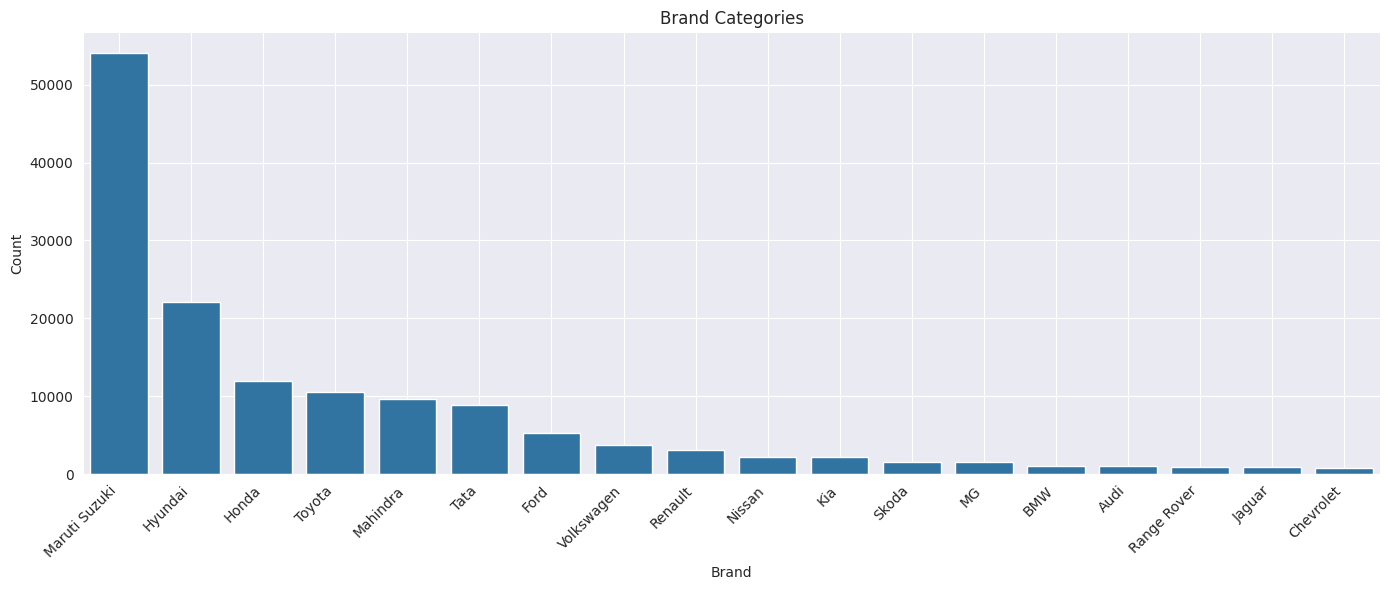

In [11]:
plt.figure(figsize=(14, 6))

sns.barplot(x=labels, y=counts)

plt.xticks(rotation=45, ha='right')  # Rotate labels
plt.title("Brand Categories")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Maruti Suzuki dominates the dataset with more than 50k listings, indicating strong representation in the Indian used-car market.</li>
        <li>Hyundai, Honda, Toyota, Mahindra, and Tata form the second tier of most common brands.</li>
        <li>Luxury brands such as BMW, Audi, Jaguar, and Range Rover have significantly fewer samples.</li>
        <li>The dataset is highly imbalanced across brands, which may cause the model to learn pricing patterns better for popular brands than luxury brands.</li>
    </ol>
</div>

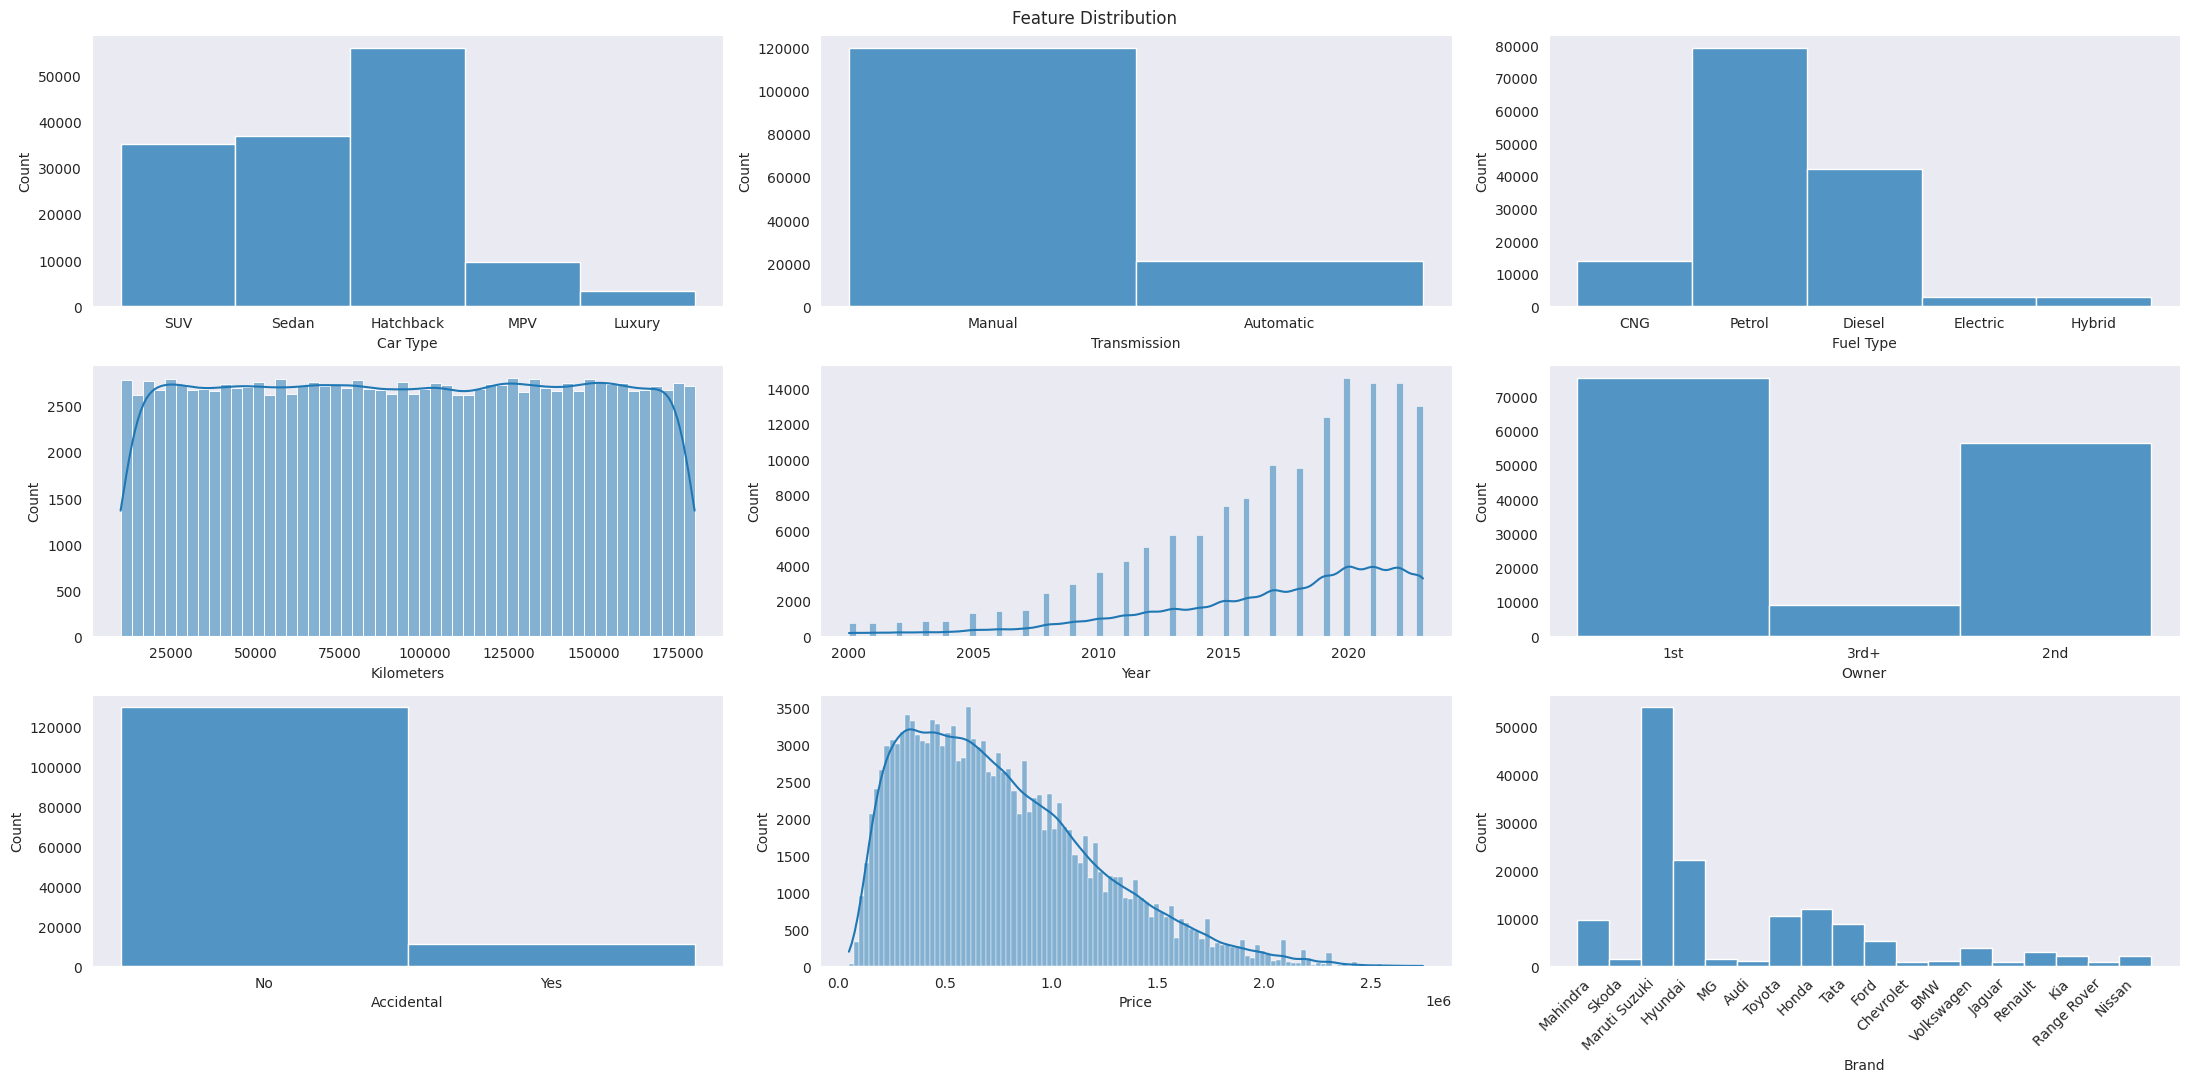

In [12]:
fig, axes = plt.subplots(3,3,figsize=(22,11))
sns.histplot(ax=axes[0,0], data=df, x="Car Type")
sns.histplot(ax=axes[0,1], data=df, x="Transmission")
sns.histplot(ax=axes[0,2], data=df, x="Fuel Type")
sns.histplot(ax=axes[1,0], data=df, x="Kilometers", kde=True)
sns.histplot(ax=axes[1,1], data=df, x="Year", kde=True)
sns.histplot(ax=axes[1,2], data=df, x="Owner")
sns.histplot(ax=axes[2,0], data=df, x="Accidental")
sns.histplot(ax=axes[2,1], data=df, x="Price", kde=True)
sns.histplot(ax=axes[2,2], data=df, x="Brand")
plt.xticks(rotation=45, ha='right')  # Rotate labels
plt.suptitle("Feature Distribution")
plt.tight_layout()
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ul style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li><b>Car Type:</b> The Indian used-car market remains heavily driven by affordable hatchback vehicles.</li>
        <li><b>Transmission:</b> Transmission is likely a significant feature affecting price.</li>
        <li><b>Fuel Type:</b> Electric vehicles remain underrepresented in the used-car market.</li>
        <li><b>Kilometers:</b> The model will be exposed to vehicles across a wide range of usage conditions.</li>
        <li><b>Year:</b> Used-car buyers tend to prefer newer vehicles.</li>
        <li><b>Owner Type:</b> Buyers generally prefer vehicles with fewer ownership transfers.</li>
        <li><b>Accidental History:</b> This is an important but imbalanced feature.</li>
        <li><b>Price Distribution:</b> Apply a log transform (np.log1p(price)) to reduce skewness and improve model performance.</li>
    </ul>
</div>

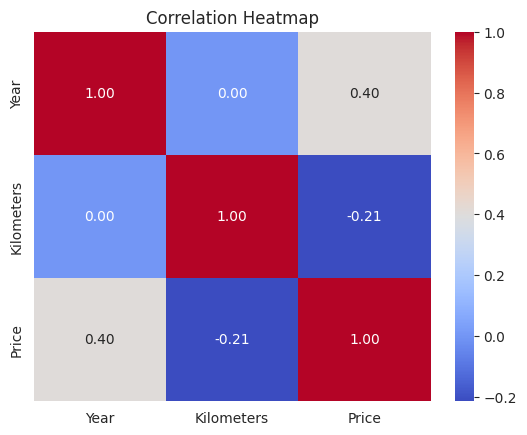

In [13]:
num_cols = df.select_dtypes(include="number").columns
correlation_mat = df[num_cols].corr()
sns.heatmap(
    correlation_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Positive correlation (0.41) between Year and Price newer vehicles tend to be more expensive.</li>
        <li>Kilometers vs Price (-0.21) shows a weak negative relationship — cars with higher mileage generally sell for lower prices.</li>
        <li>Since correlations are relatively weak, tree-based models such as XGBoost, LightGBM, and Random Forest are likely to outperform simple linear models.</li>
    </ol>
</div>v

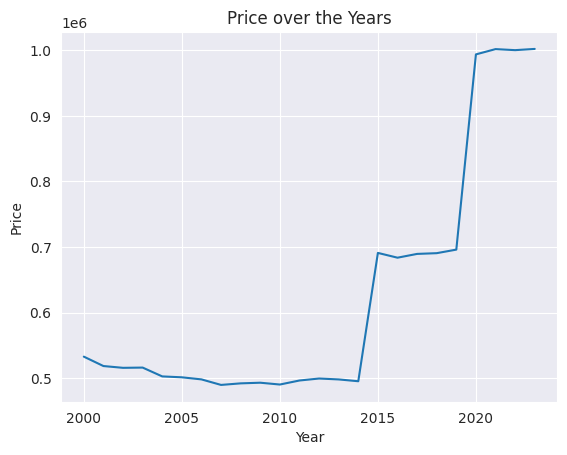

In [14]:
#Price trend over the years
sns.lineplot(
    data=df,
    x="Year",
    y="Price",
    errorbar=None
)
plt.title("Price over the Years")
sns.set_style("dark")
plt.grid(True)
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Average vehicle price generally increases with manufacturing year.</li>
        <li>There is a significant jump after 2015.</li>
        <li>Recency has a strong impact on resale value.</li>
        <li>Year should be treated as a key predictive feature.</li>
    </ol>
</div>

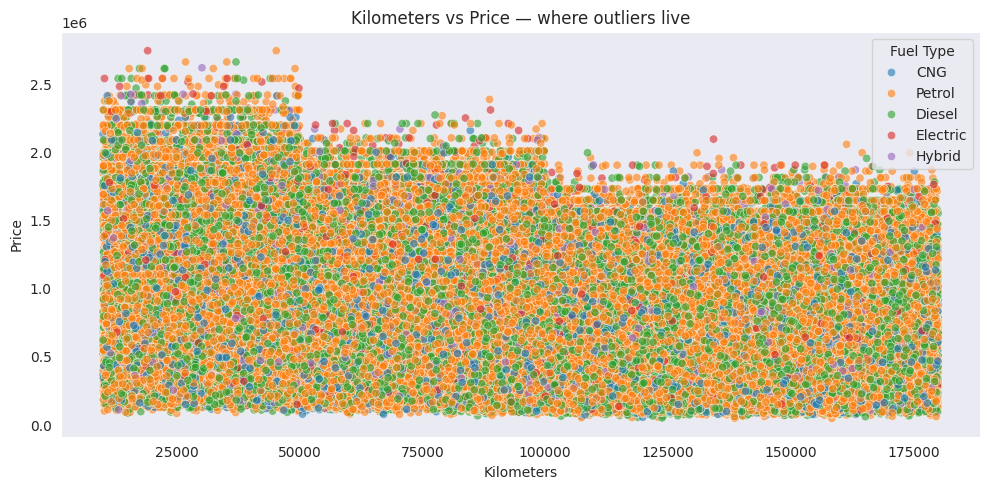

In [15]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x="Kilometers",y="Price",hue="Fuel Type",alpha=0.6)
plt.title("Kilometers vs Price — where outliers live")
plt.tight_layout()
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Higher mileage generally corresponds to lower vehicle prices.</li>
        <li>The relationship is not strictly linear.</li>
        <li>Mileage alone cannot explain price, brand, year, fuel type, ownership, and accident history must also be considered.</li>
        <li>Potential anomalies can be identified where:
            <ul style="margin: 4px 0 0 0; padding-left: 18px;">
                <li>High-mileage cars are listed at unusually high prices.</li>
                <li>Low-mileage cars are listed at suspiciously low prices.</li>
            </ul>
        </li>
    </ol>
    <p style="margin: 8px 0 0 0; color: #102A43; font-size: 14px;"><b>→ These become candidates for the fraud detection system.</b></p>
</div>

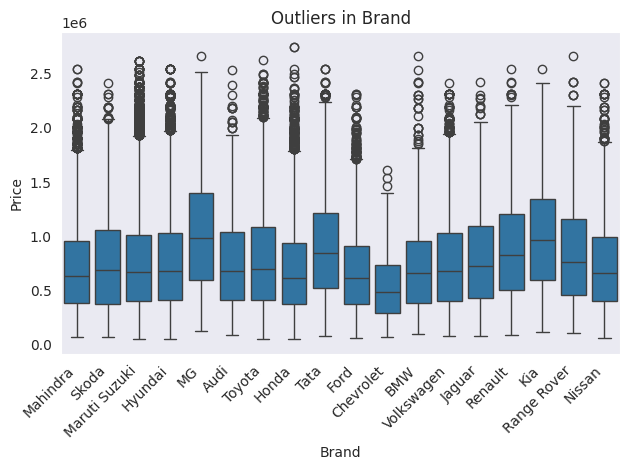

In [16]:
sns.boxplot(data=df, x="Brand", y="Price")
plt.xticks(rotation=45, ha='right')  # Rotate labels
plt.title("Outliers in Brand")
plt.tight_layout()
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Luxury-oriented brands such as MG, Kia, Range Rover, and Audi have higher median prices.</li>
        <li>Mainstream brands such as Maruti, Hyundai, and Tata exhibit lower median prices.</li>
        <li>Every brand contains several high-price outliers.</li>
        <li>The extreme points above the boxplot whiskers are natural candidates for anomaly detection.</li>
    </ol>
</div>

<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">4. EDA Conclusion</h2>
</div>

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 18px 20px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 16px; display: block; margin-bottom: 10px;">📌 Summary of Findings</span>
    <ul style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li><b>Price is driven by many factors, not one.</b> Manufacturing year, mileage, brand, ownership history, transmission type, fuel type, and accident history all shape resale value, with year showing the strongest single correlation (0.41).</li>
        <li><b>The dataset is heavily imbalanced across brands.</b> Maruti Suzuki alone contributes over 50k listings while luxury brands are sparse, so models may learn mainstream pricing patterns far better than luxury ones.</li>
        <li><b>The target variable is skewed and outlier-heavy.</b> Price exhibits significant right-skew, so a log transform (np.log1p) and robust, tree-based ensembles such as XGBoost and LightGBM are suitable modeling choices.</li>
        <li><b>Recency commands a premium.</b> Average prices climb with manufacturing year, with a notable jump after 2015, confirming year as a key predictive feature.</li>
        <li><b>Mileage matters but is not decisive.</b> Kilometers vs Price shows only a weak negative relationship (-0.21), meaning high-mileage/high-price and low-mileage/low-price listings stand out as suspicious deviations.</li>
        <li><b>Anomalies are visible and exploitable.</b> Pricing outliers appear across every brand and mileage range — these extreme points are natural candidates for the fraud detection component.</li>
    </ul>
</div>

<div style="background: linear-gradient(135deg, #73d2de 0%, #218fa3 100%); padding: 20px 25px; border-radius: 10px; box-shadow: 0 4px 15px rgba(0,0,0,0.15); margin: 20px 0;">
    <p style="color: white; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 0; font-size: 15px; line-height: 1.6;">
        <b>Takeaway:</b> The EDA validates the feasibility of a dual-purpose system one that estimates fair market value from features like year, mileage, brand, and ownership history, and simultaneously flags suspiciously overpriced or underpriced listings as potential fraud. The weak individual correlations and abundant outliers point clearly toward tree-based ensemble models and anomaly detection techniques as the right next step.
    </p>
</div>